<a href="https://colab.research.google.com/github/gabrielgomes14/tcc-cnn/blob/main/TCC_Pneus_Colab_definitivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecção de Desgaste em Pneus com CNNs — TCC
**Gabriel Gomes Galikosky** · IFC Campus Araquari · 2026

Comparação de três arquiteturas (Baseline, VGG16, ResNet50) para classificar
a condição de pneus em `good`, `worn` e `cracked`.

> Em **Ambiente de execução → Alterar tipo de hardware**, selecione **GPU (T4)**.


## 1. Setup — clonar/enviar o projeto e instalar dependências

In [1]:
# Se o projeto estiver no GitHub, clone-o; senão, faça upload da pasta src/ e scripts/.
!git clone https://github.com/gabrielgomes14/tcc-cnn.git
!pip -q install opencv-python-headless split-folders

Cloning into 'tcc-cnn'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 32 (delta 7), reused 20 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 28.57 KiB | 9.52 MiB/s, done.
Resolving deltas: 100% (7/7), done.


## 2. Dados
Escolha **A** (datasets reais do Kaggle) ou **B** (sintéticos, só para testar).

In [2]:
# --- Opção A: Kaggle (requer kaggle.json) ---
# from google.colab import files; files.upload()  # envie kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
%cd /content/tcc-cnn
!python scripts/download_data.py --dest data/raw

# --- Opção B: dados sintéticos (smoke test) ---
# !python /content/tcc-cnn/scripts/make_synthetic_data.py --dest data/raw --per-class 60

/content/tcc-cnn
You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [3]:
!mkdir -p ~/.kaggle

In [4]:
with open("/root/.kaggle/access_token", "w") as f:
    f.write("KGAT_2808c0dcdf05f559a63c737177f3c8ff")

In [5]:
!chmod 600 ~/.kaggle/access_token

In [6]:
!kaggle datasets list

ref                                                          title                                             size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  ------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
laveshjadon/ai-impact-on-students                            Impact of Ai on Students                       1187170  2026-05-10 23:12:10.070000           8740        211                1  
datasnaek/youtube-new                                        Trending YouTube Video Statistics            210575746  2019-06-03 00:56:47.177000         306358       5938        0.7941176  
nolanbconaway/pitchfork-data                                 18,393 Pitchfork Reviews                      34891456  2017-01-13 04:18:10.113000          18029        460        0.7058824  
rtatman/188-million-us-wildfires                       

In [7]:
!python scripts/download_data.py

[kaggle] Baixando warcoder/tyre-quality-classification -> data/raw/tyre_quality
Dataset URL: https://www.kaggle.com/datasets/warcoder/tyre-quality-classification
License(s): Attribution 4.0 International (CC BY 4.0)
100% 2.66G/2.66G [02:44<00:00, 17.3MB/s]

[kaggle] Baixando jehanbhathena/tire-texture-image-recognition -> data/raw/tire_texture
Dataset URL: https://www.kaggle.com/datasets/jehanbhathena/tire-texture-image-recognition
License(s): CC0-1.0
100% 708M/708M [00:40<00:00, 18.4MB/s]

[ok] Datasets em data/raw. Confira se os caminhos contêm os rótulos de origem (good/defective/normal/cracked).


## 3. Consolidação + divisão estratificada (70/15/15, seed=42)

In [8]:
from src import data_setup
from src.config import default_config, RANDOM_SEED
cfg = default_config()
print(data_setup.consolidate(cfg.raw_dir, cfg.consolidated_dir))
print(data_setup.split_dataset(cfg.consolidated_dir, cfg.split_dir,
      ratios=(cfg.train_ratio, cfg.val_ratio, cfg.test_ratio), seed=RANDOM_SEED))

{'good': 965, 'worn': 472, 'cracked': 536, '_duplicates_skipped': 911}
{'train': {'good': 676, 'worn': 330, 'cracked': 375}, 'val': {'good': 145, 'worn': 71, 'cracked': 80}, 'test': {'good': 144, 'worn': 71, 'cracked': 81}}


## 4. Visualizar efeito do CLAHE (experimento auxiliar)

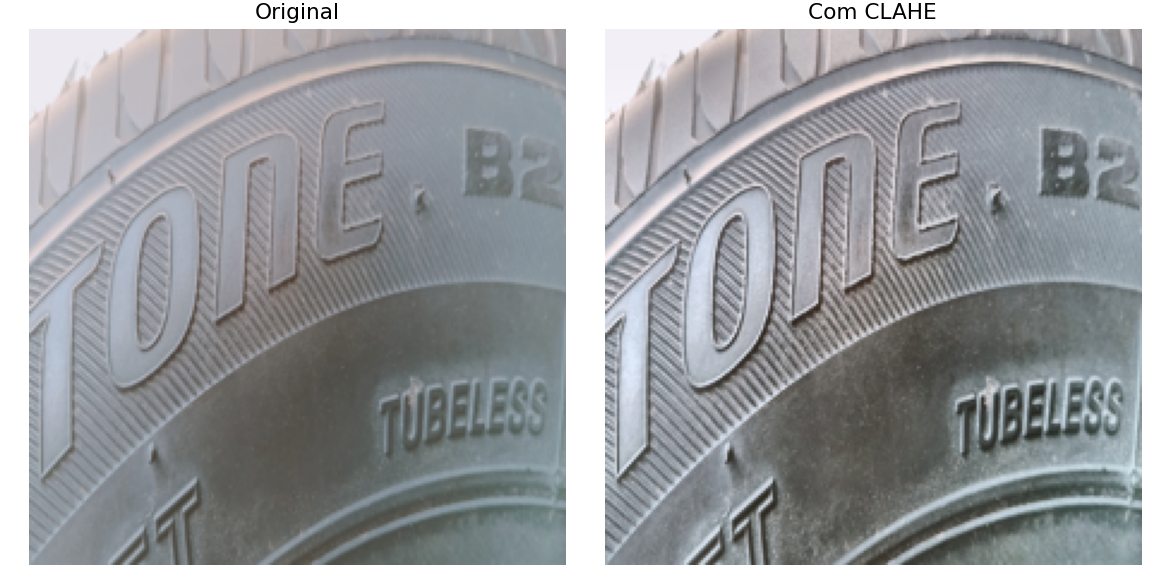

In [9]:
import glob
from src.preprocessing import preview_clahe
sample = glob.glob('data/consolidated/good/*')[0]
preview_clahe(sample, cfg, 'outputs/clahe_preview.png')
from IPython.display import Image; Image('outputs/clahe_preview.png')

## 5. Executar o experimento completo
Os 3 modelos, com e sem CLAHE. Em GPU, use as 50 épocas padrão (sem `--quick`).

In [10]:
import tensorflow as tf
base = tf.keras.applications.ResNet50(weights=None, include_top=False, input_shape=(224,224,3))
# Mostrar as últimas 20 camadas
for layer in base.layers[-20:]:
    print(layer.name)

conv5_block2_1_conv
conv5_block2_1_bn
conv5_block2_1_relu
conv5_block2_2_conv
conv5_block2_2_bn
conv5_block2_2_relu
conv5_block2_3_conv
conv5_block2_3_bn
conv5_block2_add
conv5_block2_out
conv5_block3_1_conv
conv5_block3_1_bn
conv5_block3_1_relu
conv5_block3_2_conv
conv5_block3_2_bn
conv5_block3_2_relu
conv5_block3_3_conv
conv5_block3_3_bn
conv5_block3_add
conv5_block3_out


In [ ]:
!rm -rf outputs/

In [11]:
# 2. Roda tudo novamente
!python -m scripts.run_experiment \
    --models baseline vgg16 resnet50 \
    --clahe both \
    --rebuild

[dados] Consolidando datasets de data/raw ...
[dados] Consolidado: {'good': 965, 'worn': 472, 'cracked': 536, '_duplicates_skipped': 911}
[dados] Dividindo (70/15/15, estratificado, seed=42) ...
[dados] Divisão: {'train': {'good': 676, 'worn': 330, 'cracked': 375}, 'val': {'good': 145, 'worn': 71, 'cracked': 80}, 'test': {'good': 144, 'worn': 71, 'cracked': 81}}
[dados] Contagem por split: {'train': {'good': 676, 'worn': 330, 'cracked': 375}, 'val': {'good': 145, 'worn': 71, 'cracked': 80}, 'test': {'good': 144, 'worn': 71, 'cracked': 81}}
[dados] Pesos de classe: {0: 0.6809664694280079, 1: 1.394949494949495, 2: 1.2275555555555555}
Found 1381 images belonging to 3 classes.
Found 296 images belonging to 3 classes.
Found 296 images belonging to 3 classes.

=== Treinando baseline ===
2026-06-09 14:42:24.835563: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value

## 6. Resultados
Tabela comparativa, relatório e gráficos em `outputs/`.


In [12]:
from IPython.display import Markdown
Markdown(open('outputs/RELATORIO.md', encoding='utf-8').read())


# Relatório do Experimento — Comparação de Arquiteturas CNN

Classificação da condição de pneus (good / worn / cracked).

- Modelos: baseline, vgg16, resnet50
- CLAHE: both
- Semente: 42
- Imagens por split: `{'train': {'good': 676, 'worn': 330, 'cracked': 375}, 'val': {'good': 145, 'worn': 71, 'cracked': 80}, 'test': {'good': 144, 'worn': 71, 'cracked': 81}}`

## Tabela comparativa

| modelo | clahe | acuracia | f1_macro | f1_weighted | f1_good | f1_worn | f1_cracked | params_total | params_trainable | epocas | tempo_por_epoca_s | tempo_total_treino_s | inferencia_ms_img |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| baseline | False | 0.6757 | 0.6654 | 0.6758 | 0.7108 | 0.6443 | 0.641 | 3453667 | 3452963 | 28 | 82.52 | 2313.97 | 45.805 |
| vgg16 | False | 0.9324 | 0.931 | 0.9325 | 0.9399 | 0.9452 | 0.908 | 14846787 | 7211523 | 21 | 81.56 | 1715.95 | 47.878 |
| resnet50 | False | 0.6554 | 0.6454 | 0.6569 | 0.694 | 0.6094 | 0.6327 | 24113027 | 15501315 | 23 | 82.72 | 1905.76 | 47.328 |
| baseline_clahe | True | 0.75 | 0.7443 | 0.7525 | 0.7846 | 0.7547 | 0.6936 | 3453667 | 3452963 | 37 | 84.96 | 3147.2 | 48.231 |
| vgg16_clahe | True | 0.9189 | 0.915 | 0.9191 | 0.9333 | 0.9091 | 0.9024 | 14846787 | 7211523 | 25 | 84.19 | 2107.9 | 49.272 |
| resnet50_clahe | True | 0.6993 | 0.6671 | 0.6909 | 0.7781 | 0.662 | 0.5612 | 24113027 | 15501315 | 26 | 84.91 | 2211.24 | 49.458 |

### Análise de sobreposição de erros

- Imagens de teste avaliadas: **296**
- Erros do modelo `baseline`: **96**
- Erros do modelo `vgg16`: **20**
- Erros do modelo `resnet50`: **102**
- Erros comuns a TODOS os modelos: **10** (imagens intrinsecamente difíceis)
- Erros exclusivos de um único modelo: **80** (específicos da arquitetura)

**Jaccard par a par (interseção/união das máscaras de erro):**
- `baseline` vs `vgg16`: 0.137
- `baseline` vs `resnet50`: 0.424
- `vgg16` vs `resnet50`: 0.099


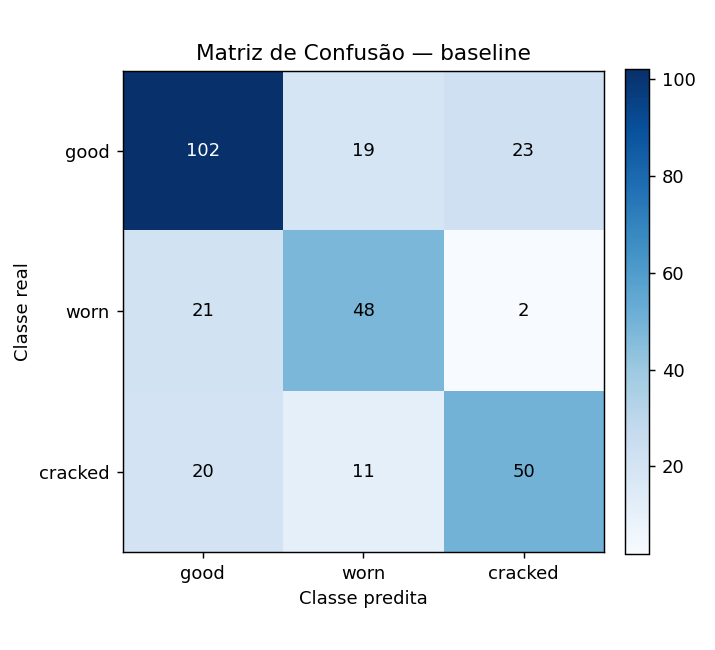

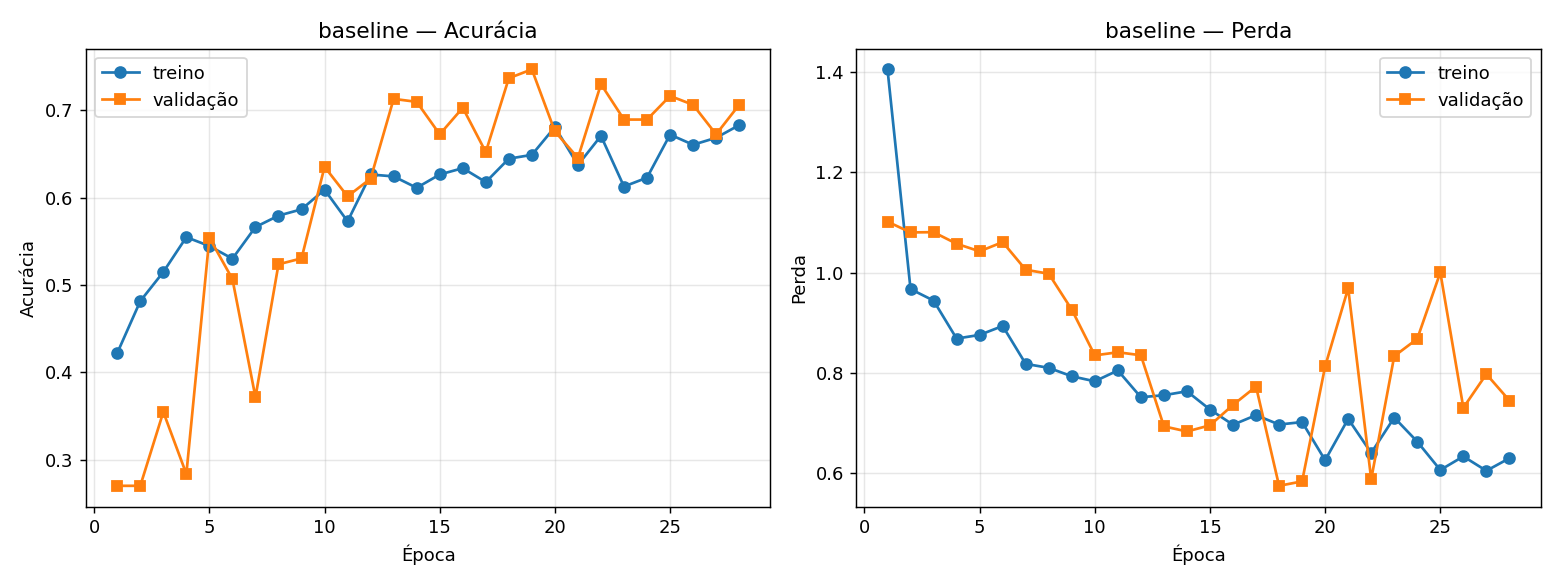

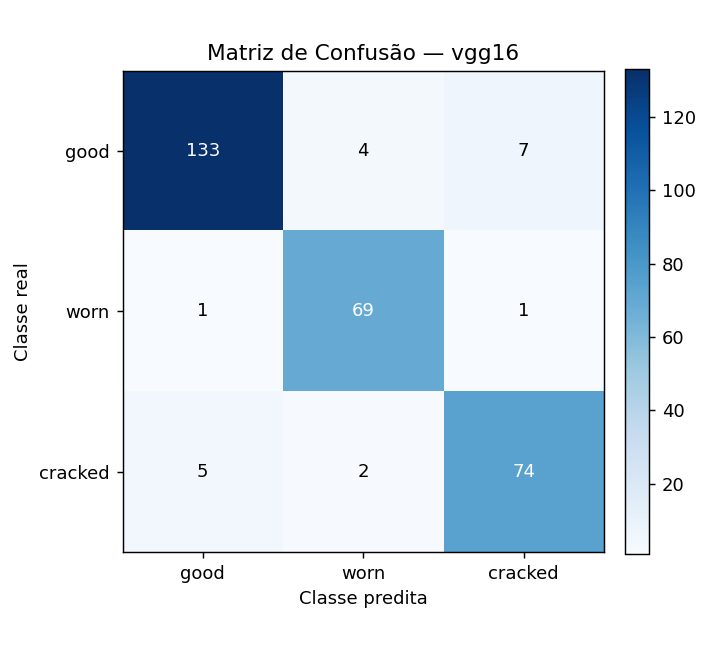

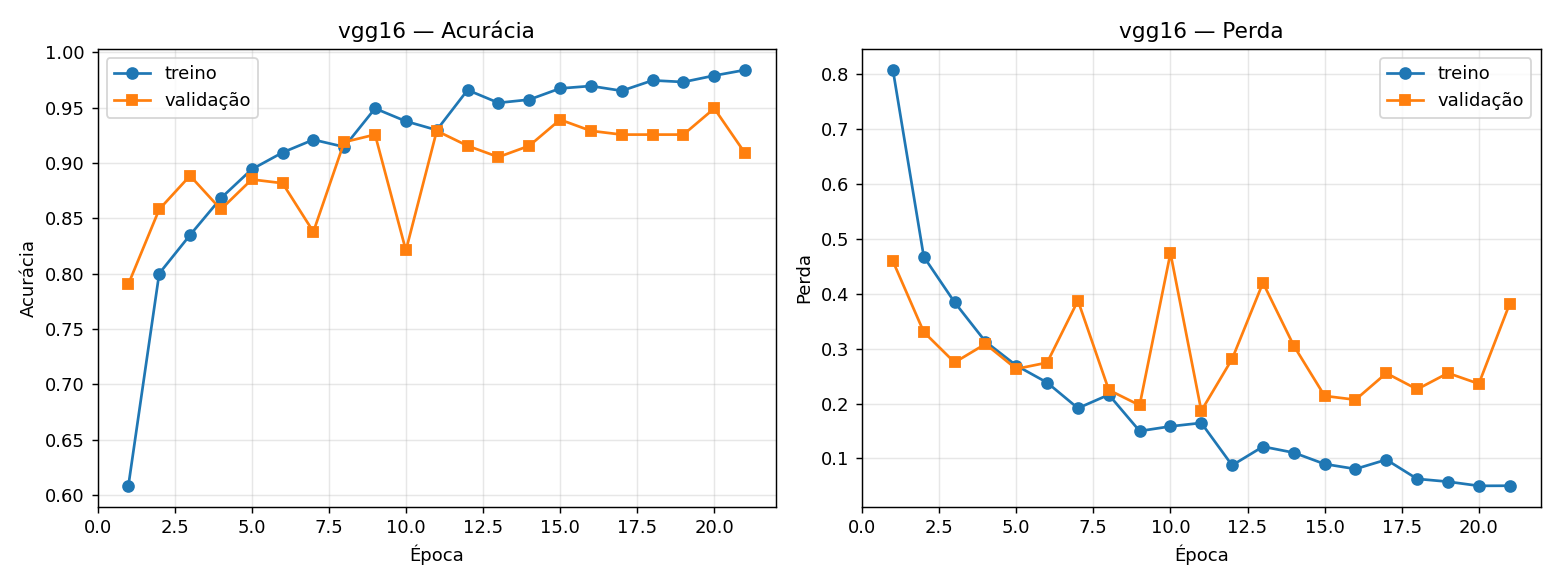

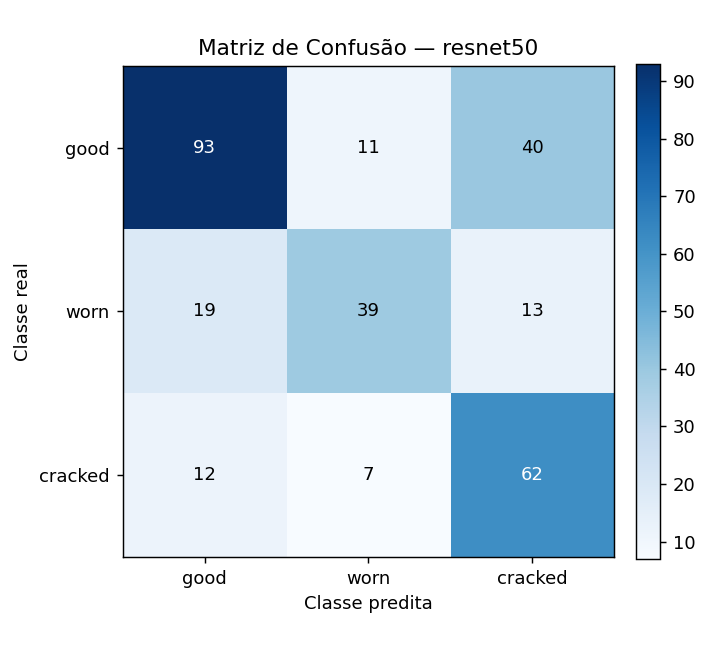

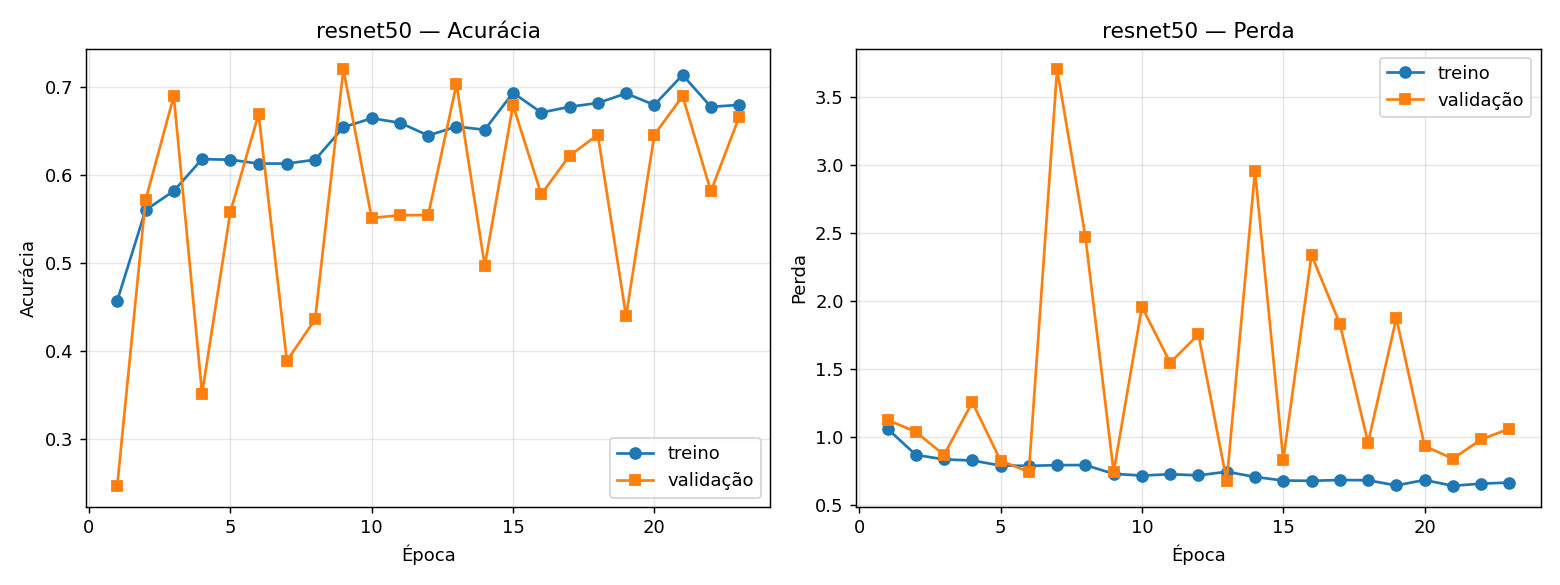

In [13]:
from IPython.display import Image
for m in ['baseline','vgg16','resnet50']:
    display(Image(f'outputs/{m}/confusion_matrix.png'))
    display(Image(f'outputs/{m}/learning_curves.png'))
